In [1]:
import pandas as pd
from sklearn.datasets import make_blobs

In [2]:
a=make_blobs()
print (a)

(array([[-5.5368546 ,  9.55026164],
       [-1.94365334,  2.59472025],
       [ 0.06385711,  2.20759343],
       [-6.81415132, -0.1378303 ],
       [-3.54110071,  9.46830643],
       [-4.14864786, -0.72996818],
       [-0.17808047,  1.71745166],
       [-6.06388723,  8.12503597],
       [-5.09304084,  8.37695423],
       [-7.59731494, -0.38416158],
       [-5.27585335,  6.64716695],
       [-7.30810294, -1.66169854],
       [-2.96411717,  8.69346023],
       [-3.19760581, 10.29481011],
       [-6.4707251 , -2.26546553],
       [-5.89216722, -0.56846807],
       [-5.96399626, -1.5295494 ],
       [-2.59836196,  0.94074737],
       [-4.06221286,  9.08170852],
       [-0.80259586, -0.23639769],
       [-4.88329046,  8.0274997 ],
       [-1.72535824,  1.81270557],
       [-5.0810304 ,  8.41018611],
       [-7.4781878 , -1.87014703],
       [-4.53709004,  6.17281979],
       [-4.65370746,  7.7151512 ],
       [-2.36443452,  0.26611128],
       [ 0.28481102,  1.00985967],
       [-1.64167831

In [3]:
#The make_blobs() function returns a tuple where the first element is your data (features) and the second is the labels.
#You need to select only the data part for scaling. I will fix this by modifying the line to scale only the feature matrix.

from sklearn.preprocessing import StandardScaler
a_scaled = StandardScaler().fit_transform(a[0])
print(a_scaled)

[[-0.53809022  1.4917508 ]
 [ 1.02927884 -0.07683781]
 [ 1.9049631  -0.16414125]
 [-1.09525227 -0.69307276]
 [ 0.33246577  1.47326856]
 [ 0.06745122 -0.82660956]
 [ 1.79942894 -0.27467626]
 [-0.76798401  1.17033905]
 [-0.34449685  1.22715074]
 [-1.43687144 -0.7486245 ]
 [-0.42424041  0.83705536]
 [-1.31071599 -1.03673003]
 [ 0.58414835  1.29852804]
 [ 0.48229965  1.65965869]
 [-0.94544835 -1.17288938]
 [-0.69307904 -0.79018863]
 [-0.72441116 -1.00692823]
 [ 0.74369226 -0.44983581]
 [ 0.10515453  1.38608439]
 [ 1.52701277 -0.71530132]
 [-0.25300288  1.14834302]
 [ 1.12450005 -0.25319494]
 [-0.33925785  1.23464508]
 [-1.3849077  -1.08373858]
 [-0.10198884  0.73008229]
 [-0.15285783  1.07790331]
 [ 0.84573237 -0.60197731]
 [ 2.0013441  -0.43424985]
 [ 1.16100158 -0.57378244]
 [-0.4214575   1.54170651]
 [-1.81154181 -1.32685502]
 [ 1.5018803  -0.71488843]
 [-0.41822823  1.44121265]
 [ 1.28244681 -0.48014716]
 [ 0.99996459 -0.15477157]
 [ 0.95013958 -0.35055857]
 [-0.50963866  1.01047826]
 

In [4]:
#from numpy.random import RandomState
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state = 42)
kmeans.fit(a_scaled)

KMeans(n_clusters=3, random_state=42)

In [5]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(a_scaled)
    wcss.append(kmeans.inertia_)

In [6]:
wcss

[200.00000000000006,
 119.62767063957914,
 23.687448088311655,
 19.133253621242,
 14.993262288962903,
 14.26563806323458,
 10.200978363032291,
 8.405305726411417,
 7.856263790439453,
 6.763397967979572]

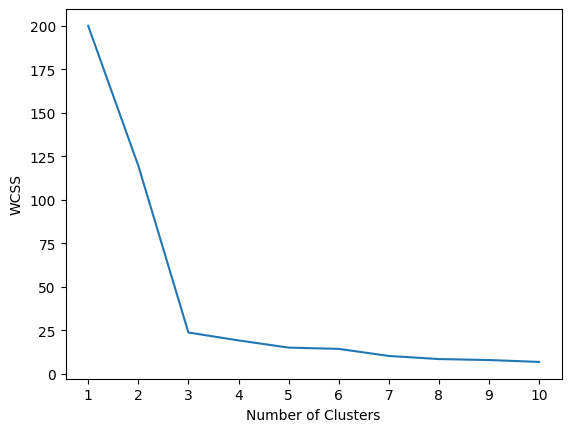

In [7]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [8]:
kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit(a_scaled)

KMeans(n_clusters=3)

In [9]:
print(kmeans.labels_)

[0 2 2 1 0 1 2 0 0 1 0 1 0 0 1 1 1 2 0 2 0 2 0 1 0 0 2 2 2 0 1 2 0 2 2 2 0
 0 0 1 2 0 1 1 2 2 1 1 1 0 1 2 0 2 1 2 1 1 2 2 1 1 0 1 2 0 1 2 0 2 0 0 1 1
 1 0 2 1 1 2 2 2 0 2 0 1 1 2 0 0 0 2 2 0 1 0 1 0 2 2]


In [10]:
kpred = kmeans.predict(a_scaled)
print(kpred)

[0 2 2 1 0 1 2 0 0 1 0 1 0 0 1 1 1 2 0 2 0 2 0 1 0 0 2 2 2 0 1 2 0 2 2 2 0
 0 0 1 2 0 1 1 2 2 1 1 1 0 1 2 0 2 1 2 1 1 2 2 1 1 0 1 2 0 1 2 0 2 0 0 1 1
 1 0 2 1 1 2 2 2 0 2 0 1 1 2 0 0 0 2 2 0 1 0 1 0 2 2]


In [11]:
print(kmeans.cluster_centers_)

[[-0.21098662  1.31820325]
 [-1.02316274 -0.96065562]
 [ 1.17396331 -0.41405678]]


In [12]:
print(kmeans.labels_)

[0 2 2 1 0 1 2 0 0 1 0 1 0 0 1 1 1 2 0 2 0 2 0 1 0 0 2 2 2 0 1 2 0 2 2 2 0
 0 0 1 2 0 1 1 2 2 1 1 1 0 1 2 0 2 1 2 1 1 2 2 1 1 0 1 2 0 1 2 0 2 0 0 1 1
 1 0 2 1 1 2 2 2 0 2 0 1 1 2 0 0 0 2 2 0 1 0 1 0 2 2]


In [13]:
from sklearn.metrics import silhouette_score

silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(a_scaled)
    score = silhouette_score(a_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [14]:
silhouette_coefficients

[np.float64(0.5125491134203298),
 np.float64(0.7158022297350108),
 np.float64(0.6001294012628842),
 np.float64(0.5296319473243749),
 np.float64(0.5125401480984286),
 np.float64(0.4437319529449123),
 np.float64(0.43444278113014645),
 np.float64(0.3769063462734346),
 np.float64(0.38858711275531305)]

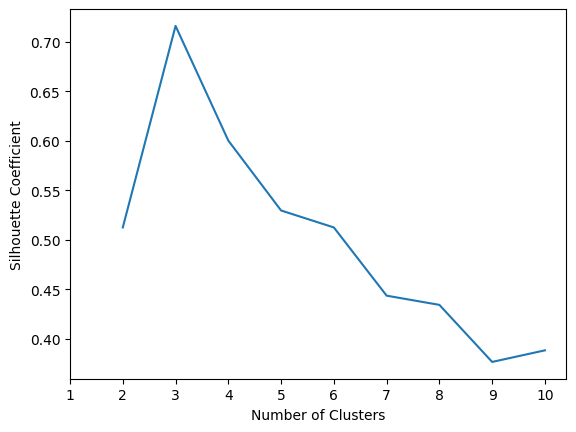

In [15]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()